# 2.2

dependencies

In [97]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator
import scipy.optimize as opt

In [98]:
# Data Path initialization

# Determine script directory
base_path = Path.cwd()

# Paths for data and images
data_path = base_path / 'Data' / 'Datasheet.xlsx'
img_path = base_path.parent / 'Images'

# import data from path
Data = pd.read_excel(data_path, sheet_name='Bolzmannkonst', engine='openpyxl')

In [99]:
U40 =  np.array([[x, y] for x, y in zip(Data['U (T=40 C)'].tolist(), Data['Error U (T=40 C)'].tolist())])
U40 = U40[~np.isnan(U40).all(axis=1)]
I40 = np.array([[x, y] for x, y in zip(Data['I (T=40 C)'].tolist(), Data['Error I (T=40 C)'].tolist())])
I40 = I40[~np.isnan(I40).all(axis=1)]

U80 = np.array([[x, y] for x, y in zip(Data['U (T=80 C)'].tolist(), Data['Error U (T=80 C)'].tolist())])
U80 = U80[~np.isnan(U80).all(axis=1)]
I80 = np.array([[x, y] for x, y in zip(Data['I (T=80 C)'].tolist(), Data['Error I (T=80 C)'].tolist())])
I80 = I80[~np.isnan(I80).all(axis=1)]

U120 = np.array([[x, y] for x, y in zip(Data['U (T=120 C)'].tolist(), Data['Error U (T=120 C)'].tolist())])
U120 = U120[~np.isnan(U120).all(axis=1)]
I120 = np.array([[x, y] for x, y in zip(Data['I (T=120 C)'].tolist(), Data['Error I (T=120 C)'].tolist())])
I120 = I120[~np.isnan(I120).all(axis=1)]

In [100]:
e = 1.602176634e-19  # elementary charge in coulombs

def lin(x,a,b):
    return a*x + b

def k(a, T):
    return 1/a * e/(T)

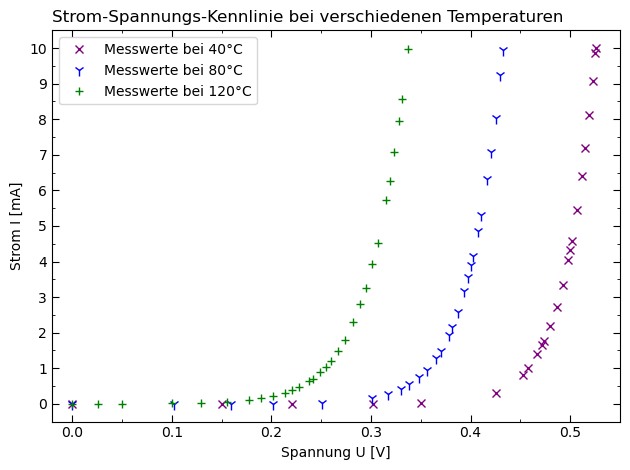

In [ ]:
plt.plot(U40[:,0], I40[:,0], 'x', color='purple', label='Messwerte bei 40°C')
plt.plot(U80[:,0], I80[:,0], '1', color='blue', label='Messwerte bei 80°C', markersize=8)
plt.plot(U120[:,0], I120[:,0], '+', color='green', label='Messwerte bei 120°C')

plt.xlabel('Spannung U [V]')
plt.ylabel('Strom I [mA]')
plt.title('Strom-Spannungs-Kennlinie bei verschiedenen Temperaturen', loc='left')

plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.xticks(np.arange(-1, 1.5, 0.1))
plt.yticks(np.arange(-5, 12, 1))
plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)

plt.ylim(-0.5, 10.5)
plt.xlim(-0.02, 0.55)
plt.tight_layout()
plt.legend()

plt.savefig(img_path / 'BoltzAll.png')
plt.show()

## logarithmic fit on 40 Celsius

40°C: a = 35.59660 ± 0.16412, b = -16.34072 ± 0.07856


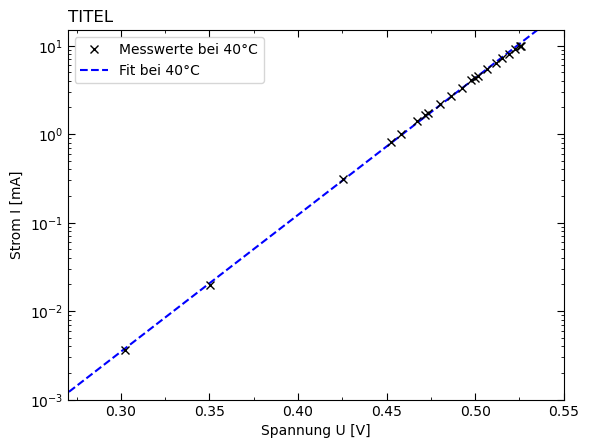

In [105]:
lim40 = 0.3

mask40 = U40[:,0] >= lim40

params40, cov40 = opt.curve_fit(lin, U40[mask40,0], np.log(I40[mask40,0]))
print("40°C: a = %.5f ± %.5f, b = %.5f ± %.5f" % (params40[0], np.sqrt(cov40[0,0]), params40[1], np.sqrt(cov40[1,1])))

plt.plot(U40[mask40,0], I40[mask40,0], 'x', color='black', label='Messwerte bei 40°C', zorder=3)
plt.plot(np.linspace(0,1,100), np.exp(lin(np.linspace(0,1,100), *params40)), linestyle='--',color='blue', label='Fit bei 40°C', zorder=2)
plt.yscale('log') 

plt.xlabel('Spannung U [V]')
plt.ylabel('Strom I [mA]')
plt.title('TITEL', loc='left')

plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.xticks(np.arange(0, 0.7, 0.05))
plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)

plt.ylim(1e-3, 1.5e1)
plt.xlim(0.27, 0.55)
plt.legend()

plt.savefig(img_path / 'Boltz40.png')
plt.show()


In [ ]:
k40 = k(params40[0], 313.15)
print(k40)

1.4373068800551707e-23
